# Custom CNN — GTSRB Traffic Sign Classification

**Owner:** Naweedh
**Model:** Custom CNN (trained from scratch, no pretrained weights)
**Framework:** PyTorch

This notebook trains and evaluates the group's from-scratch baseline under the group's
**Finalized Experiment Configuration**, so the results are directly comparable with ResNet50,
MobileNetV3Large and EfficientNetB0.

| Setting | Value |
|---|---|
| Dataset / classes | GTSRB, 43 classes, RGB 64×64×3 (shared `gtsrb_data.npz`) |
| Train / validation | 85% / 15% stratified split of the official training set (seed 42, shared `.npz` as-is) |
| Test | Official GTSRB test set, unseen until final evaluation |
| Batch size / max epochs | 32 / 30 |
| Early stopping | patience 5, monitoring validation loss |
| Checkpoint | lowest validation-loss model |
| Optimizer | Adam, constant LR 0.001 |
| Loss | Sparse categorical cross-entropy |
| Output | 43 neurons + softmax |
| Augmentation (train only) | rotation ±10°, width/height shift ±10%, zoom ±10%, mild brightness; **no flips** |
| Metrics | Accuracy (primary); macro precision, recall, F1; confusion matrix |

| Section | Contents |
|---|---|
| 0 | Environment setup (Colab or local) |
| 1 | Imports, config, seeding |
| 2 | Load the shared split |
| 3 | Preprocessing & augmentation |
| 4 | Model architecture + design rationale |
| 5 | Training (train/val only) |
| 6 | Learning curves |
| 7 | Final test-set evaluation |
| 8 | Error analysis |
| 9 | Efficiency (params, size, inference time) |
| 10 | Ablation: effect of augmentation |
| 11 | Save config & metrics |

## 0. Environment setup

- **Colab:** Runtime → Change runtime type → **T4 GPU**. The cell below mounts Google Drive and uses
  `MyDrive/DL_GroupProject`. Put `gtsrb_data.npz` in `MyDrive/DL_GroupProject/data/processed/`.
  Outputs are written to Drive, so they survive a runtime reset.
- **Local:** run the notebook from the `notebooks/` folder or from the repo root.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/DL_GroupProject")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "https://github.com/AaqibAR/DL_GroupProject.git", str(ROOT)], check=True)
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = ROOT / "data" / "processed" / "gtsrb_data.npz"
RESULTS_DIR = ROOT / "results" / "custom_cnn"
CONFIG_DIR = ROOT / "configs"
CKPT_DIR = ROOT / "checkpoints"          # gitignored — weights are not committed
for d in (RESULTS_DIR, CONFIG_DIR, CKPT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Colab:", IN_COLAB)
print("Repo root:", ROOT)
print("Data file exists:", DATA_PATH.exists())

Colab: False
Repo root: /Users/naweedhahamed/DL_GroupProject
Data file exists: True


## 1. Imports, config, seeding

In [2]:
import json
import time
import random
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report,
)

print("PyTorch:", torch.__version__)

PyTorch: 2.14.0


In [3]:
# Values under "group-fixed" come from the Finalized Experiment Configuration; don't change them.
# The architecture values are this model's own design choices.
# Everything is saved to configs/custom_cnn.json at the end.
CONFIG = {
    "model_name": "Custom CNN",
    # --- group-fixed ---
    "dataset": "GTSRB",
    "seed": 42,
    "img_size": 64,
    "num_classes": 43,
    "val_fraction": 0.15,             # 85/15 stratified split, as produced by src/data_split.py
    "batch_size": 32,
    "max_epochs": 30,
    "early_stopping_patience": 5,     # monitor: validation loss
    "checkpoint": "lowest validation loss",
    "optimizer": "Adam",
    "learning_rate": 1e-3,            # constant — no schedule for the from-scratch model
    "loss": "sparse categorical cross-entropy",
    "output": "43 neurons + softmax",
    "pretrained_weights": None,
    # --- augmentation (training set only, group-fixed) ---
    "aug_rotation_deg": 10,
    "aug_shift": 0.10,                # width and height
    "aug_zoom": 0.10,
    "aug_brightness": 0.2,            # "mild": factor sampled from [0.8, 1.2]
    "aug_flips": False,               # flips change sign meaning
    # --- architecture (Custom CNN design) ---
    "conv_channels": [32, 64, 128],   # one entry per conv block (2 conv layers per block)
    "conv_dropout": 0.2,
    "dense_units": 256,
    "fc_dropout": 0.5,
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG["seed"])

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    DEVICE_NAME = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    DEVICE_NAME = f"Apple MPS ({platform.machine()})"
else:
    DEVICE = torch.device("cpu")
    DEVICE_NAME = f"CPU ({platform.processor() or platform.machine()})"
print("Device:", DEVICE_NAME)

Device: Apple MPS (arm64)


In [4]:
# Official GTSRB class names (index = ClassId), used for readable error analysis
CLASS_NAMES = [
    "Speed limit (20km/h)", "Speed limit (30km/h)", "Speed limit (50km/h)", "Speed limit (60km/h)",
    "Speed limit (70km/h)", "Speed limit (80km/h)", "End of speed limit (80km/h)", "Speed limit (100km/h)",
    "Speed limit (120km/h)", "No passing", "No passing for vehicles over 3.5t",
    "Right-of-way at next intersection", "Priority road", "Yield", "Stop", "No vehicles",
    "Vehicles over 3.5t prohibited", "No entry", "General caution", "Dangerous curve left",
    "Dangerous curve right", "Double curve", "Bumpy road", "Slippery road", "Road narrows on the right",
    "Road work", "Traffic signals", "Pedestrians", "Children crossing", "Bicycles crossing",
    "Beware of ice/snow", "Wild animals crossing", "End of all speed and passing limits",
    "Turn right ahead", "Turn left ahead", "Ahead only", "Go straight or right", "Go straight or left",
    "Keep right", "Keep left", "Roundabout mandatory", "End of no passing",
    "End of no passing by vehicles over 3.5t",
]
assert len(CLASS_NAMES) == CONFIG["num_classes"]

## 2. Load the shared split

The shared `gtsrb_data.npz` (from `src/data_split.py`) holds an 85/15 stratified train/validation split of
the official training set (seed 42) and the official test set. All images are resized to 64×64 and scaled
to [0, 1]. The split is used **as-is**, exactly as the other three models use it.
The train and val arrays are stored together with index arrays, so the dataset code can serve both.

**The test arrays are not used until Section 7.**

In [5]:
data = np.load(DATA_PATH)
X_all = np.concatenate([data["X_train"], data["X_val"]])   # official training set: shared train + val
y_all = np.concatenate([data["y_train"], data["y_val"]])
X_test, y_test = data["X_test"], data["y_test"]
n_train = len(data["y_train"])
del data

train_idx = np.arange(n_train)                  # shared train part
val_idx = np.arange(n_train, len(y_all))        # shared val part
y_train, y_val = y_all[train_idx], y_all[val_idx]

print(f"Official training set: {len(y_all)} -> train {len(train_idx)} ({len(train_idx) / len(y_all):.1%}) "
      f"/ val {len(val_idx)} ({len(val_idx) / len(y_all):.1%})")
print(f"Official test set: {len(y_test)}")
print(f"Image shape {X_all.shape[1:]}, dtype {X_all.dtype}, range [{X_all.min():.2f}, {X_all.max():.2f}]")

counts = np.bincount(y_train, minlength=CONFIG["num_classes"])
print(f"Train class counts: min={counts.min()} (class {counts.argmin()}), "
      f"max={counts.max()} (class {counts.argmax()}), imbalance ratio={counts.max() / counts.min():.1f}")

split_summary = pd.DataFrame({
    "class_id": range(CONFIG["num_classes"]),
    "class": CLASS_NAMES,
    "train": counts,
    "val": np.bincount(y_val, minlength=CONFIG["num_classes"]),
    "test": np.bincount(y_test, minlength=CONFIG["num_classes"]),
})
split_summary.to_csv(RESULTS_DIR / "split_class_counts.csv", index=False)

Official training set: 39209 -> train 33327 (85.0%) / val 5882 (15.0%)
Official test set: 12630


Image shape (64, 64, 3), dtype float32, range [0.00, 1.00]
Train class counts: min=179 (class 0), max=1912 (class 2), imbalance ratio=10.7


## 3. Preprocessing & augmentation

- **Scaling:** pixels are already in [0, 1] from the shared pipeline. No further normalisation, so all
  models start from the same input.
- **Augmentation (train only):** rotation ±10°, width/height shift ±10%, zoom ±10% and mild brightness
  variation. These imitate the viewpoint, distance and lighting changes in real dashcam frames.
- **No horizontal or vertical flips:** flipping changes what many signs mean (*Turn left* ↔ *Turn right*,
  *Keep left* ↔ *Keep right*, *Dangerous curve left* ↔ *right*), so it would create wrongly labelled images.

In [6]:
augment_transform = v2.Compose([
    v2.RandomAffine(
        degrees=CONFIG["aug_rotation_deg"],
        translate=(CONFIG["aug_shift"], CONFIG["aug_shift"]),
        scale=(1 - CONFIG["aug_zoom"], 1 + CONFIG["aug_zoom"]),
    ),
    v2.ColorJitter(brightness=CONFIG["aug_brightness"]),
])


class GTSRBDataset(Dataset):
    # Serves CHW tensors from the NHWC float array, restricted to the given indices
    def __init__(self, X, y, indices=None, transform=None):
        self.X = torch.from_numpy(X).permute(0, 3, 1, 2)
        self.y = torch.from_numpy(y).long()
        self.indices = np.arange(len(y)) if indices is None else indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        j = self.indices[i]
        img = self.X[j]
        if self.transform is not None:
            img = self.transform(img).clamp(0, 1)
        return img, self.y[j]


# Worker processes don't work well with notebook-defined classes on macOS, so only use them on CUDA
NUM_WORKERS = 2 if DEVICE.type == "cuda" else 0
PIN = DEVICE.type == "cuda"


def make_train_loader(augment):
    ds = GTSRBDataset(X_all, y_all, train_idx, augment_transform if augment else None)
    return DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=True,
                      generator=torch.Generator().manual_seed(CONFIG["seed"]),
                      num_workers=NUM_WORKERS, pin_memory=PIN)


val_loader = DataLoader(GTSRBDataset(X_all, y_all, val_idx), batch_size=256, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=PIN)
test_loader = DataLoader(GTSRBDataset(X_test, y_test), batch_size=256, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN)
print(f"Batches/epoch: train={len(make_train_loader(True))} val={len(val_loader)}")

Batches/epoch: train=1042 val=23


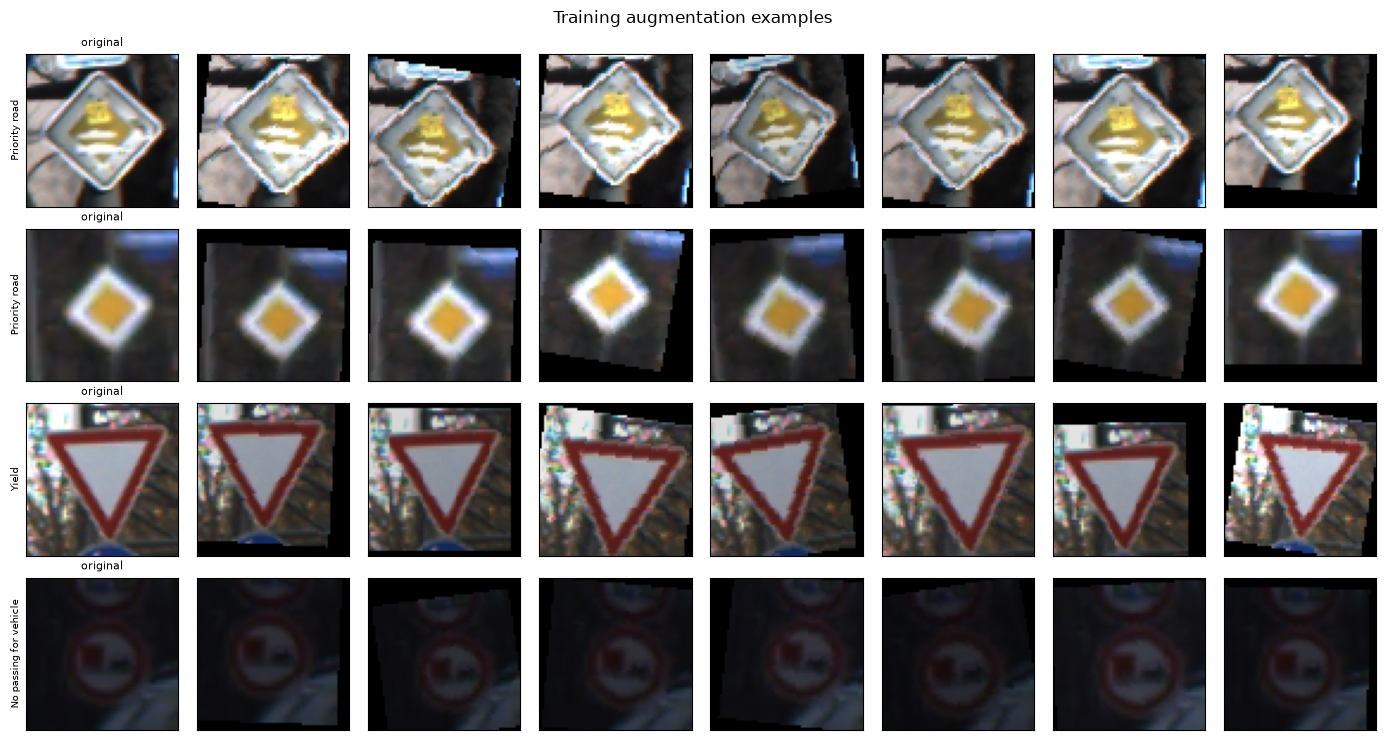

In [7]:
# Visual check: each row is one training image, then 7 random augmentations of it (figure for the report)
rng = np.random.default_rng(CONFIG["seed"])
fig, axes = plt.subplots(4, 8, figsize=(14, 7.5))
for row, idx in zip(axes, rng.choice(train_idx, 4, replace=False)):
    original = torch.from_numpy(X_all[idx]).permute(2, 0, 1)
    row[0].imshow(X_all[idx])
    row[0].set_title("original", fontsize=8)
    for ax in row[1:]:
        ax.imshow(augment_transform(original).clamp(0, 1).permute(1, 2, 0).numpy())
    row[0].set_ylabel(CLASS_NAMES[y_all[idx]][:22], fontsize=7)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Training augmentation examples")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "augmentation_examples.png", dpi=150)
plt.show()

## 4. Model architecture

```
Input 3×64×64
 └─ Block 1: [Conv3×3(32) → BN → ReLU] ×2 → MaxPool 2×2 → Dropout2d(0.2)   → 32×32×32
 └─ Block 2: [Conv3×3(64) → BN → ReLU] ×2 → MaxPool 2×2 → Dropout2d(0.2)   → 64×16×16
 └─ Block 3: [Conv3×3(128) → BN → ReLU] ×2 → MaxPool 2×2 → Dropout2d(0.2)  → 128×8×8
 └─ Flatten (8192) → Dense(256) → BN → ReLU → Dropout(0.5) → Dense(43) → Softmax
```

**Design rationale** (for the report):
- **Stacked 3×3 convolutions** (VGG-style): two 3×3 layers see the same 5×5 area as one 5×5 layer, but with
  fewer parameters and an extra non-linearity.
- **Channels double (32→64→128) as the image halves:** early layers pick up edges and colours, deeper layers
  pick up shapes, digits and symbols.
- **3 pooling stages:** 64→8 px, which is still enough to tell apart small details like "30" vs "80".
- **Batch normalisation:** makes training steadier at the fixed learning rate of 1e-3. The conv layers have
  no bias because BN already adds one.
- **ReLU** in hidden layers, **softmax** over 43 outputs. In PyTorch the final layer returns logits and
  `CrossEntropyLoss` applies log-softmax inside the loss. With integer labels this is exactly sparse
  categorical cross-entropy, and it is more numerically stable than a separate softmax layer. Softmax is
  applied explicitly at prediction time.
- **Dropout** (light in the conv blocks, 0.5 before the classifier) limits overfitting. Most parameters are
  in the 8192→256 dense layer, so that is where overfitting is most likely.
- **No pretrained weights:** this is the from-scratch baseline that shows what transfer learning adds.

In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.block(x)


class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes, img_size, conv_channels, conv_dropout, dense_units, fc_dropout):
        super().__init__()
        blocks, in_ch = [], 3
        for out_ch in conv_channels:
            blocks.append(ConvBlock(in_ch, out_ch, conv_dropout))
            in_ch = out_ch
        self.features = nn.Sequential(*blocks)

        spatial = img_size // (2 ** len(conv_channels))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch * spatial * spatial, dense_units, bias=False),
            nn.BatchNorm1d(dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(fc_dropout),
            nn.Linear(dense_units, num_classes),   # 43 logits; softmax applied in loss / at prediction
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_model():
    return TrafficSignCNN(
        num_classes=CONFIG["num_classes"], img_size=CONFIG["img_size"],
        conv_channels=CONFIG["conv_channels"], conv_dropout=CONFIG["conv_dropout"],
        dense_units=CONFIG["dense_units"], fc_dropout=CONFIG["fc_dropout"],
    ).to(DEVICE)


model = build_model()
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal parameters: {n_params:,}  (trainable: {n_trainable:,})")

# Parameters per layer (for the complexity discussion)
layer_params = pd.DataFrame(
    [(name, tuple(p.shape), p.numel()) for name, p in model.named_parameters()],
    columns=["parameter", "shape", "count"],
)
layer_params["% of total"] = (100 * layer_params["count"] / n_params).round(2)
layer_params.to_csv(RESULTS_DIR / "layer_parameters.csv", index=False)
layer_params.sort_values("count", ascending=False).head(8)

TrafficSignCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.2, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_si

,parameter,shape,count,% of total
18,classifier.1.weight,"(256, 8192)",2097152,87.52
15,features.2.block.3.weight,"(128, 128, 3, 3)",147456,6.15
12,features.2.block.0.weight,"(128, 64, 3, 3)",73728,3.08
9,features.1.block.3.weight,"(64, 64, 3, 3)",36864,1.54
6,features.1.block.0.weight,"(64, 32, 3, 3)",18432,0.77
21,classifier.5.weight,"(43, 256)",11008,0.46
3,features.0.block.3.weight,"(32, 32, 3, 3)",9216,0.38
0,features.0.block.0.weight,"(32, 3, 3, 3)",864,0.04


## 5. Training

- **Loss:** sparse categorical cross-entropy (integer class labels).
- **Optimizer:** Adam with a constant learning rate of 0.001 for the whole run. There are no pretrained
  weights, so there are no freeze/unfreeze phases.
- **Early stopping:** training stops after 5 epochs without a new lowest validation loss (max 30 epochs).
- **Checkpoint:** the lowest-validation-loss weights are saved and reloaded as the final model.
- **Model selection uses validation data only.** The test set is not used here.

`train_model` is a function so that the augmentation ablation (Section 10) runs under exactly the same
conditions.

In [9]:
criterion = nn.CrossEntropyLoss()   # integer labels -> sparse categorical cross-entropy


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            n += yb.size(0)
    return total_loss / n, correct / n


def train_model(augment, tag):
    set_seed(CONFIG["seed"])
    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    train_loader = make_train_loader(augment)
    ckpt_path = CKPT_DIR / f"custom_cnn_{tag}_best.pt"

    history = []
    best_val_loss, best_epoch, epochs_no_improve = float("inf"), 0, 0
    start = time.perf_counter()
    for epoch in range(1, CONFIG["max_epochs"] + 1):
        t0 = time.perf_counter()
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader)
        epoch_time = time.perf_counter() - t0
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc, "epoch_time_s": epoch_time})

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss, best_epoch, epochs_no_improve = val_loss, epoch, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_no_improve += 1

        print(f"[{tag}] Epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f} | {epoch_time:.1f}s"
              + ("  *best*" if improved else ""), flush=True)

        if epochs_no_improve >= CONFIG["early_stopping_patience"]:
            print(f"[{tag}] Early stopping: no val-loss improvement for {epochs_no_improve} epochs.")
            break

    train_time_s = time.perf_counter() - start
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"history_{tag}.csv", index=False)
    info = {"best_epoch": best_epoch, "best_val_loss": best_val_loss, "epochs_run": len(history),
            "train_time_s": train_time_s, "stopped_early": len(history) < CONFIG["max_epochs"],
            "ckpt_path": ckpt_path}
    print(f"[{tag}] Training time {train_time_s / 60:.1f} min | epochs run {len(history)} | best epoch {best_epoch}")
    return model, history_df, info


model, history_df, train_info = train_model(augment=True, tag="main")

[main] Epoch 01 | train loss 1.6230 acc 0.5125 | val loss 0.2132 acc 0.9504 | 116.8s  *best*


[main] Epoch 02 | train loss 0.3560 acc 0.8954 | val loss 0.0263 acc 0.9940 | 89.5s  *best*


[main] Epoch 03 | train loss 0.1690 acc 0.9501 | val loss 0.0133 acc 0.9971 | 77.2s  *best*


[main] Epoch 04 | train loss 0.1176 acc 0.9648 | val loss 0.0072 acc 0.9980 | 74.7s  *best*


[main] Epoch 05 | train loss 0.0906 acc 0.9723 | val loss 0.0041 acc 0.9991 | 75.1s  *best*


...

[main] Epoch 27 | train loss 0.0246 acc 0.9929 | val loss 0.0010 acc 0.9997 | 109.1s


[main] Epoch 28 | train loss 0.0241 acc 0.9928 | val loss 0.0011 acc 0.9998 | 158.2s


[main] Epoch 29 | train loss 0.0179 acc 0.9943 | val loss 0.0010 acc 0.9995 | 168.1s


[main] Early stopping: no val-loss improvement for 5 epochs.


[main] Training time 53.0 min | epochs run 29 | best epoch 24


## 6. Learning curves

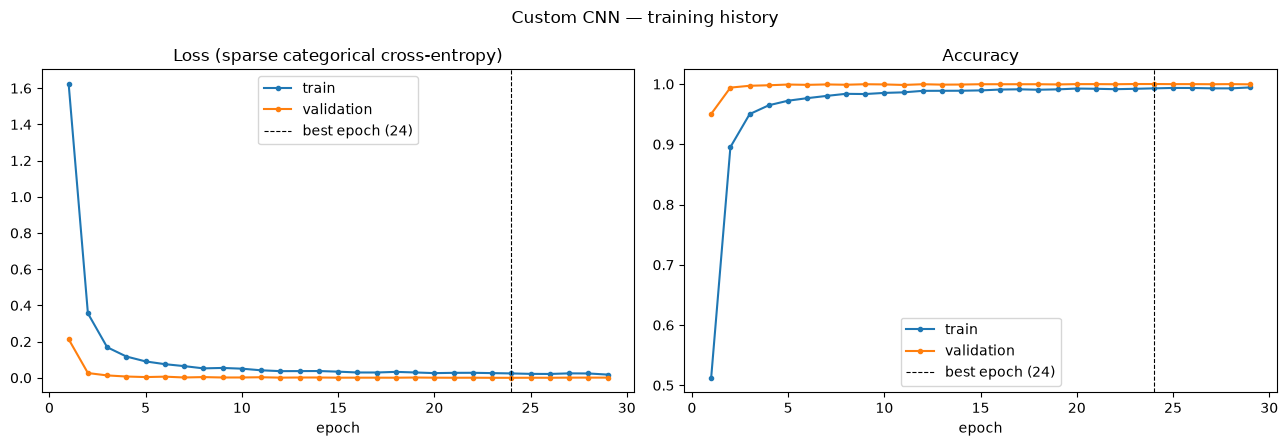

Best epoch 24: train loss 0.0243 / val loss 0.0001; train acc 0.9928 / val acc 1.0000 (gap -0.0072)
Note: train metrics are measured on augmented images with dropout active, val metrics on clean images in eval mode, so val can be higher than train.


In [10]:
best_epoch = train_info["best_epoch"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history_df.epoch, history_df.train_loss, marker=".", label="train")
axes[0].plot(history_df.epoch, history_df.val_loss, marker=".", label="validation")
axes[0].set_title("Loss (sparse categorical cross-entropy)")
axes[1].plot(history_df.epoch, history_df.train_acc, marker=".", label="train")
axes[1].plot(history_df.epoch, history_df.val_acc, marker=".", label="validation")
axes[1].set_title("Accuracy")
for ax in axes:
    ax.axvline(best_epoch, ls="--", c="k", lw=0.8, label=f"best epoch ({best_epoch})")
    ax.set_xlabel("epoch")
    ax.legend()
plt.suptitle("Custom CNN — training history")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "learning_curves.png", dpi=150)
plt.show()

best_row = history_df.loc[history_df.epoch == best_epoch].iloc[0]
print(f"Best epoch {best_epoch}: train loss {best_row.train_loss:.4f} / val loss {best_row.val_loss:.4f}; "
      f"train acc {best_row.train_acc:.4f} / val acc {best_row.val_acc:.4f} "
      f"(gap {best_row.train_acc - best_row.val_acc:+.4f})")
print("Note: train metrics are measured on augmented images with dropout active, "
      "val metrics on clean images in eval mode, so val can be higher than train.")

## 7. Final test-set evaluation

This is the **first time the test set is used**. The model is the lowest-validation-loss checkpoint.

**Group evaluation template:** accuracy (primary metric), macro precision, macro recall, macro F1 and
the confusion matrix. Macro averaging counts each of the 43 classes equally, so weak rare classes show up.
Weighted averages and one-vs-rest ROC-AUC are also reported as supplementary figures.

In [11]:
def predict(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu())
    return torch.cat(probs).numpy()


def template_metrics(y_true, probs):
    y_pred = probs.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision_macro": p, "recall_macro": r, "f1_macro": f1}


val_probs = predict(model, val_loader)
test_probs = predict(model, test_loader)
test_pred = test_probs.argmax(1)

val_metrics = template_metrics(y_val, val_probs)
test_metrics = template_metrics(y_test, test_probs)

p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, test_pred, average="weighted", zero_division=0)
supplementary = {
    "precision_weighted": p_w, "recall_weighted": r_w, "f1_weighted": f1_w,
    "roc_auc_ovr_macro": roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro",
                                       labels=list(range(CONFIG["num_classes"]))),
    "n_test": int(len(y_test)), "n_misclassified": int((test_pred != y_test).sum()),
}

results_table = pd.DataFrame({"Validation": val_metrics, "Test": test_metrics}).T
results_table.columns = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
print("Custom CNN — evaluation template")
display(results_table.round(4))
print("Supplementary (test):")
pd.Series(supplementary).to_frame("Custom CNN")

Custom CNN — evaluation template


,Accuracy,Macro Precision,Macro Recall,Macro F1
Validation,1.0000,1.0000,1.0000,1.0000
Test,0.9949,0.9922,0.9935,0.9927


Supplementary (test):


,Custom CNN
precision_weighted,0.995047
recall_weighted,0.994933
f1_weighted,0.994938
roc_auc_ovr_macro,0.999990
n_test,12630.000000
n_misclassified,64.000000


In [12]:
# Per-class precision / recall / F1 on the test set
report = classification_report(y_test, test_pred, labels=list(range(CONFIG["num_classes"])),
                               target_names=CLASS_NAMES, output_dict=True, zero_division=0)
per_class = pd.DataFrame({k: report[k] for k in CLASS_NAMES}).T
per_class.index.name = "class"
per_class.insert(0, "class_id", range(CONFIG["num_classes"]))
per_class["support"] = per_class["support"].astype(int)
per_class["train_count"] = counts
per_class.to_csv(RESULTS_DIR / "per_class_metrics.csv")
print("Worst 10 classes by F1:")
per_class.sort_values("f1-score").head(10)[["class_id", "precision", "recall", "f1-score", "support", "train_count"]].round(4)

Worst 10 classes by F1:


,class_id,precision,recall,f1-score,support,train_count
class,,,,,,
Beware of ice/snow,30,0.9236,0.9667,0.9446,150,382
End of speed limit (80km/h),6,1.0000,0.9400,0.9691,150,357
Double curve,21,1.0000,0.9444,0.9714,90,281
Wild animals crossing,31,0.9642,0.9963,0.9800,270,663
No vehicles,15,0.9633,1.0000,0.9813,210,535
Right-of-way at next intersection,11,0.9951,0.9714,0.9831,420,1122
End of all speed and passing limits,32,0.9677,1.0000,0.9836,60,204
End of no passing,41,0.9677,1.0000,0.9836,60,204
Roundabout mandatory,40,1.0000,0.9778,0.9888,90,306


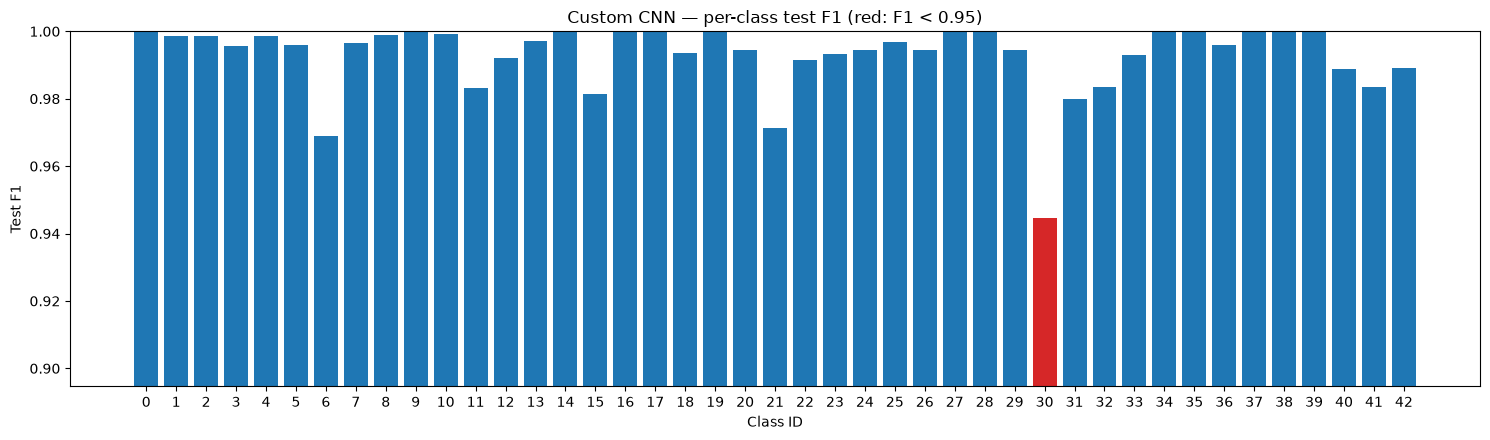

In [13]:
fig, ax = plt.subplots(figsize=(15, 4.5))
colors = ["tab:red" if f < 0.95 else "tab:blue" for f in per_class["f1-score"]]
ax.bar(per_class.class_id, per_class["f1-score"], color=colors)
ax.set_xticks(per_class.class_id)
ax.set_xlabel("Class ID"); ax.set_ylabel("Test F1")
ax.set_ylim(max(0, per_class["f1-score"].min() - 0.05), 1.0)
ax.set_title("Custom CNN — per-class test F1 (red: F1 < 0.95)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_class_f1.png", dpi=150)
plt.show()

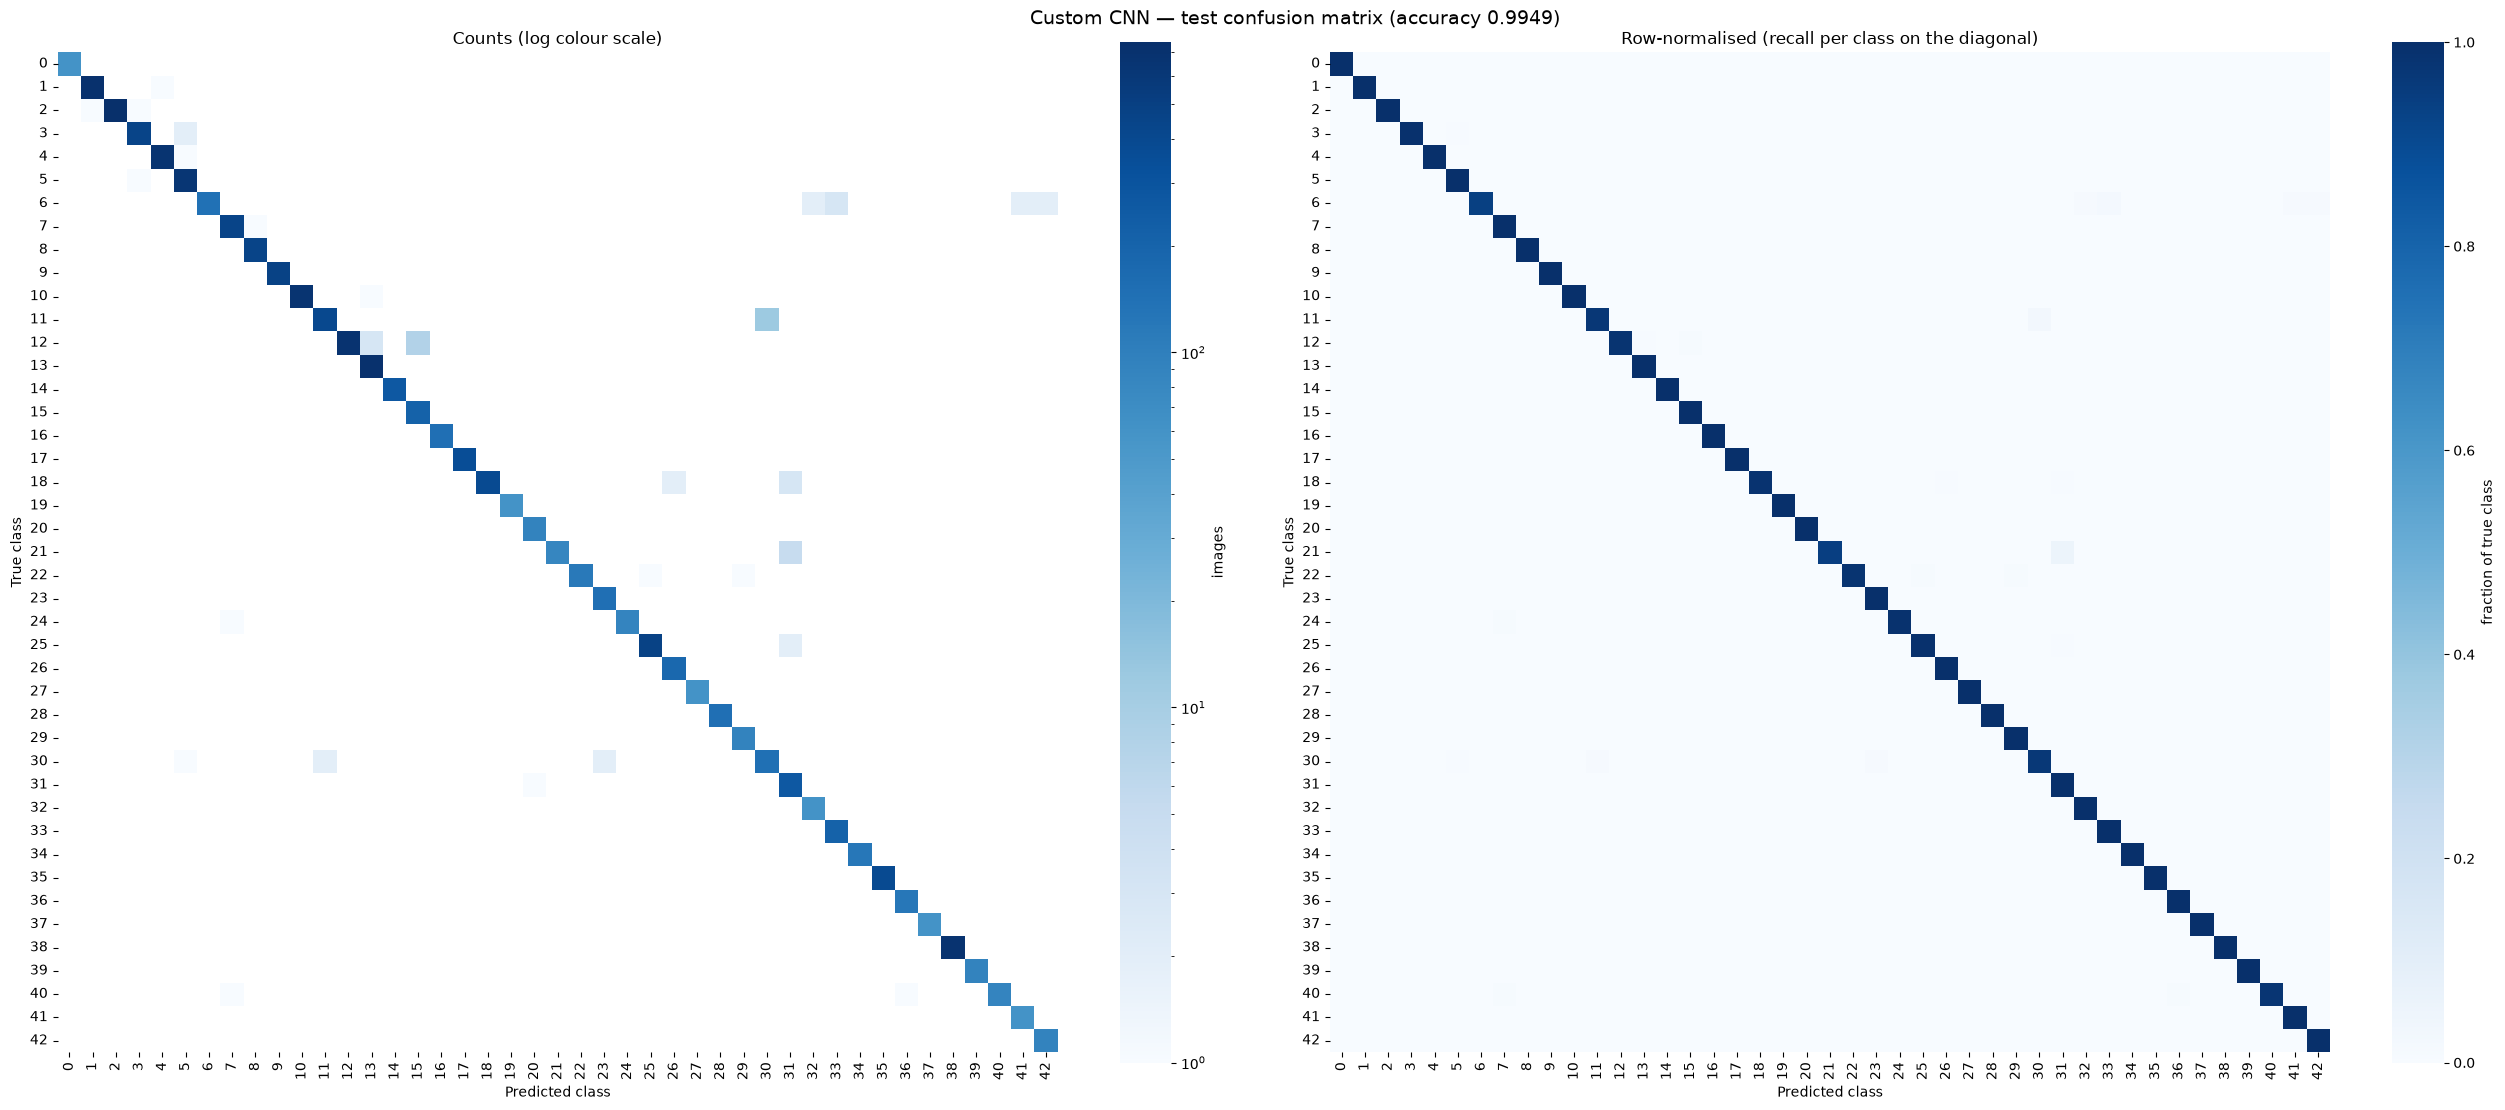

In [14]:
cm = confusion_matrix(y_test, test_pred, labels=list(range(CONFIG["num_classes"])))
np.savetxt(RESULTS_DIR / "confusion_matrix.csv", cm, fmt="%d", delimiter=",")

fig, axes = plt.subplots(1, 2, figsize=(26, 11))
sns.heatmap(cm, cmap="Blues", square=True, ax=axes[0], cbar_kws={"label": "images"},
            norm=plt.matplotlib.colors.LogNorm(vmin=1, vmax=cm.max()))
axes[0].set_title("Counts (log colour scale)")
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1, square=True, ax=axes[1],
            cbar_kws={"label": "fraction of true class"})
axes[1].set_title("Row-normalised (recall per class on the diagonal)")
for ax in axes:
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
plt.suptitle(f"Custom CNN — test confusion matrix (accuracy {test_metrics['accuracy']:.4f})", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 8. Error analysis

Which signs does the model confuse, and what do the mistakes look like? This feeds the critical-analysis
section of the report.

In [15]:
off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
pairs = [(i, j, off_diag[i, j]) for i, j in zip(*np.nonzero(off_diag))]
confused = pd.DataFrame(pairs, columns=["true_id", "pred_id", "count"]).sort_values("count", ascending=False).head(15)
confused["true"] = confused.true_id.map(lambda i: CLASS_NAMES[i])
confused["predicted"] = confused.pred_id.map(lambda i: CLASS_NAMES[i])
confused["% of true class"] = (100 * confused["count"].values / cm.sum(axis=1)[confused.true_id.values]).round(2)
confused.to_csv(RESULTS_DIR / "top_confusions.csv", index=False)
confused[["true_id", "true", "pred_id", "predicted", "count", "% of true class"]]

,true_id,true,pred_id,predicted,count,% of true class
12,11,Right-of-way at next intersection,30,Beware of ice/snow,12,2.86
14,12,Priority road,15,No vehicles,8,1.16
17,21,Double curve,31,Wild animals crossing,5,5.56
16,18,General caution,31,Wild animals crossing,3,0.77
13,12,Priority road,13,Yield,3,0.43
7,6,End of speed limit (80km/h),33,Turn right ahead,3,2.00
23,30,Beware of ice/snow,11,Right-of-way at next intersection,2,1.33
15,18,General caution,26,Traffic signals,2,0.51
21,25,Road work,31,Wild animals crossing,2,0.42
9,6,End of speed limit (80km/h),42,End of no passing by vehicles over 3.5t,2,1.33


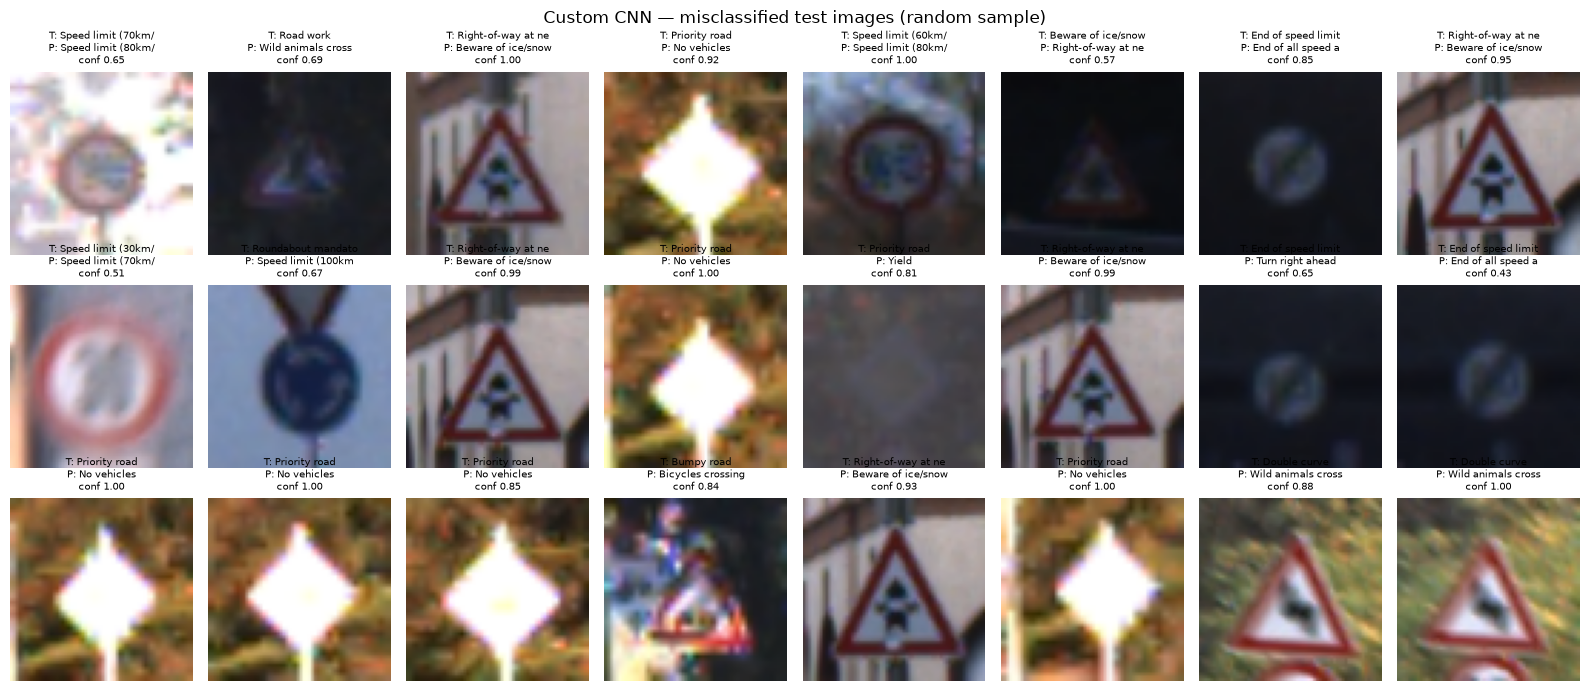

In [16]:
# Misclassified test images: true label, predicted label and confidence
wrong = np.flatnonzero(test_pred != y_test)
show = np.random.default_rng(CONFIG["seed"]).choice(wrong, min(24, len(wrong)), replace=False) if len(wrong) else []
if len(show):
    fig, axes = plt.subplots(3, 8, figsize=(16, 7))
    for ax in axes.flat:
        ax.axis("off")
    for ax, i in zip(axes.flat, show):
        ax.imshow(X_test[i])
        ax.set_title(f"T: {CLASS_NAMES[y_test[i]][:18]}\nP: {CLASS_NAMES[test_pred[i]][:18]}\n"
                     f"conf {test_probs[i, test_pred[i]]:.2f}", fontsize=7)
    plt.suptitle("Custom CNN — misclassified test images (random sample)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "misclassified_examples.png", dpi=150)
    plt.show()

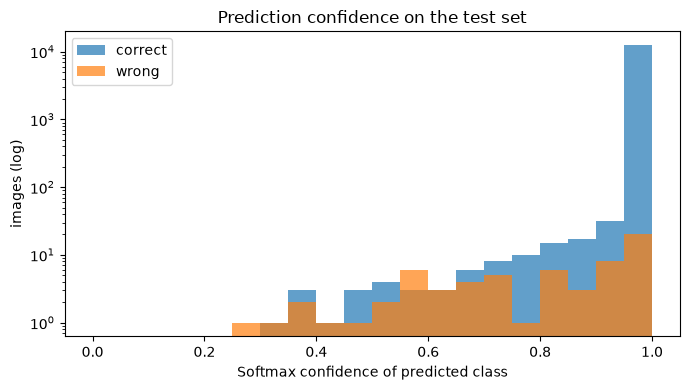

{'mean_conf_correct': 0.9980013966560364,
 'mean_conf_wrong': 0.7875063419342041,
 'wrong_with_conf_over_0.9': 28}

In [17]:
# Confidence: is the model sure of itself when it's wrong?
conf = test_probs.max(1)
correct_mask = test_pred == y_test
confidence_stats = {
    "mean_conf_correct": float(conf[correct_mask].mean()),
    "mean_conf_wrong": float(conf[~correct_mask].mean()) if (~correct_mask).any() else float("nan"),
    "wrong_with_conf_over_0.9": int(((~correct_mask) & (conf > 0.9)).sum()),
}
bins = np.linspace(0, 1, 21)
plt.figure(figsize=(7, 4))
plt.hist(conf[correct_mask], bins=bins, alpha=0.7, label="correct", log=True)
plt.hist(conf[~correct_mask], bins=bins, alpha=0.7, label="wrong", log=True)
plt.xlabel("Softmax confidence of predicted class"); plt.ylabel("images (log)")
plt.title("Prediction confidence on the test set")
plt.legend(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "confidence_histogram.png", dpi=150)
plt.show()
confidence_stats

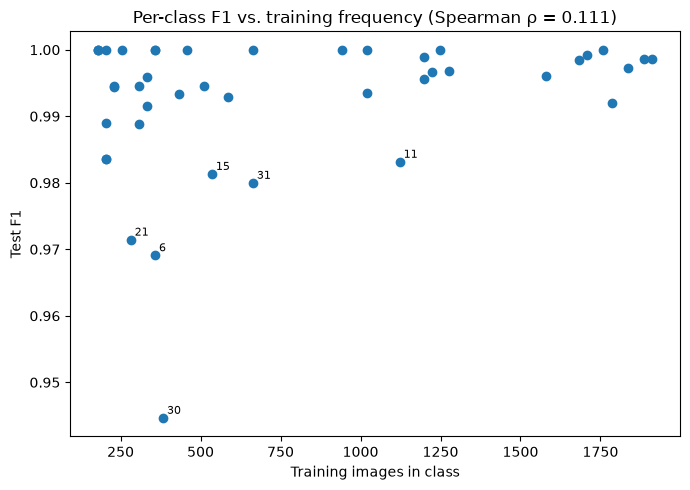

Spearman correlation: 0.111


In [18]:
# Does training-set frequency explain per-class performance? (tests the class-imbalance hypothesis)
spearman = per_class[["train_count", "f1-score"]].corr(method="spearman").iloc[0, 1]
plt.figure(figsize=(7, 5))
plt.scatter(per_class.train_count, per_class["f1-score"])
for _, r in per_class.nsmallest(6, "f1-score").iterrows():
    plt.annotate(int(r.class_id), (r.train_count, r["f1-score"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.xlabel("Training images in class"); plt.ylabel("Test F1")
plt.title(f"Per-class F1 vs. training frequency (Spearman ρ = {spearman:.3f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_vs_class_frequency.png", dpi=150)
plt.show()
print("Spearman correlation:", round(spearman, 3))

## 9. Efficiency

In [19]:
ckpt_path = train_info["ckpt_path"]
model_size_mb = ckpt_path.stat().st_size / 1024 ** 2


def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elif DEVICE.type == "mps":
        torch.mps.synchronize()


def time_inference(batch_size, reps=50):
    model.eval()
    x = torch.rand(batch_size, 3, CONFIG["img_size"], CONFIG["img_size"], device=DEVICE)
    with torch.no_grad():
        for _ in range(10):          # warm-up
            model(x)
        sync()
        t0 = time.perf_counter()
        for _ in range(reps):
            model(x)
        sync()
    return (time.perf_counter() - t0) / reps / batch_size * 1000   # ms per image


# Multiply-accumulate operations for one 64×64 image (conv + linear layers)
macs = 0
size = CONFIG["img_size"]
for m in model.modules():
    if isinstance(m, nn.Conv2d):
        macs += m.in_channels * m.out_channels * m.kernel_size[0] * m.kernel_size[1] * size * size
    elif isinstance(m, nn.MaxPool2d):
        size //= 2
    elif isinstance(m, nn.Linear):
        macs += m.in_features * m.out_features

efficiency = {
    "total_params": n_params,
    "trainable_params": n_trainable,
    "model_size_mb": round(model_size_mb, 2),
    "gmacs_per_image": round(macs / 1e9, 4),
    "train_time_min": round(train_info["train_time_s"] / 60, 2),
    "epochs_run": train_info["epochs_run"],
    "best_epoch": train_info["best_epoch"],
    "stopped_early": train_info["stopped_early"],
    "mean_epoch_time_s": round(history_df.epoch_time_s.mean(), 2),
    "inference_ms_per_image_bs1": round(time_inference(1), 3),
    "inference_ms_per_image_bs256": round(time_inference(256), 4),
    "device": DEVICE_NAME,
    "torch_version": torch.__version__,
}
pd.Series(efficiency).to_frame("Custom CNN")

,Custom CNN
total_params,2396171
trainable_params,2396171
model_size_mb,9.16
gmacs_per_image,0.1566
train_time_min,53.02
epochs_run,29
best_epoch,24
stopped_early,True
mean_epoch_time_s,109.47
inference_ms_per_image_bs1,1.387


## 10. Ablation: effect of augmentation

The same model is retrained with identical settings (seed, split, optimizer, early stopping) but
**without augmentation**. Comparing the two shows how much augmentation helps generalisation and
overfitting. The main model above was chosen before this run, and the test set played no part in any
training or selection decision.

In [20]:
model_noaug, history_noaug, info_noaug = train_model(augment=False, tag="no_aug")
val_noaug = template_metrics(y_val, predict(model_noaug, val_loader))
test_noaug = template_metrics(y_test, predict(model_noaug, test_loader))
del model_noaug


def gap_at_best(h, best):
    r = h.loc[h.epoch == best].iloc[0]
    return r.train_acc - r.val_acc, r.val_loss - r.train_loss


ablation = pd.DataFrame([
    {"run": "with augmentation", "best_epoch": train_info["best_epoch"], "epochs_run": train_info["epochs_run"],
     "train_time_min": train_info["train_time_s"] / 60,
     "train_minus_val_acc": gap_at_best(history_df, train_info["best_epoch"])[0],
     "val_minus_train_loss": gap_at_best(history_df, train_info["best_epoch"])[1],
     **{f"val_{k}": v for k, v in val_metrics.items()}, **{f"test_{k}": v for k, v in test_metrics.items()}},
    {"run": "no augmentation", "best_epoch": info_noaug["best_epoch"], "epochs_run": info_noaug["epochs_run"],
     "train_time_min": info_noaug["train_time_s"] / 60,
     "train_minus_val_acc": gap_at_best(history_noaug, info_noaug["best_epoch"])[0],
     "val_minus_train_loss": gap_at_best(history_noaug, info_noaug["best_epoch"])[1],
     **{f"val_{k}": v for k, v in val_noaug.items()}, **{f"test_{k}": v for k, v in test_noaug.items()}},
]).set_index("run")
ablation.to_csv(RESULTS_DIR / "ablation_augmentation.csv")
ablation.T.round(4)

[no_aug] Epoch 01 | train loss 0.8734 acc 0.7628 | val loss 0.0447 acc 0.9908 | 153.8s  *best*


[no_aug] Epoch 02 | train loss 0.0794 acc 0.9806 | val loss 0.0196 acc 0.9949 | 140.9s  *best*


[no_aug] Epoch 03 | train loss 0.0436 acc 0.9888 | val loss 0.0155 acc 0.9956 | 114.5s  *best*


[no_aug] Epoch 04 | train loss 0.0326 acc 0.9909 | val loss 0.0107 acc 0.9976 | 98.7s  *best*


[no_aug] Epoch 05 | train loss 0.0271 acc 0.9919 | val loss 0.0122 acc 0.9964 | 93.6s


...

[no_aug] Epoch 13 | train loss 0.0095 acc 0.9970 | val loss 0.0046 acc 0.9990 | 107.2s


[no_aug] Epoch 14 | train loss 0.0091 acc 0.9967 | val loss 0.0051 acc 0.9986 | 87.0s


[no_aug] Early stopping: no val-loss improvement for 5 epochs.


[no_aug] Training time 22.1 min | epochs run 14 | best epoch 9


run,with augmentation,no augmentation
best_epoch,24.0000,9.0000
epochs_run,29.0000,14.0000
train_time_min,53.0181,22.1243
train_minus_val_acc,-0.0072,-0.0031
val_minus_train_loss,-0.0242,-0.0092
val_accuracy,1.0000,0.9986
val_precision_macro,1.0000,0.9978
val_recall_macro,1.0000,0.9981
val_f1_macro,1.0000,0.9979
test_accuracy,0.9949,0.9869


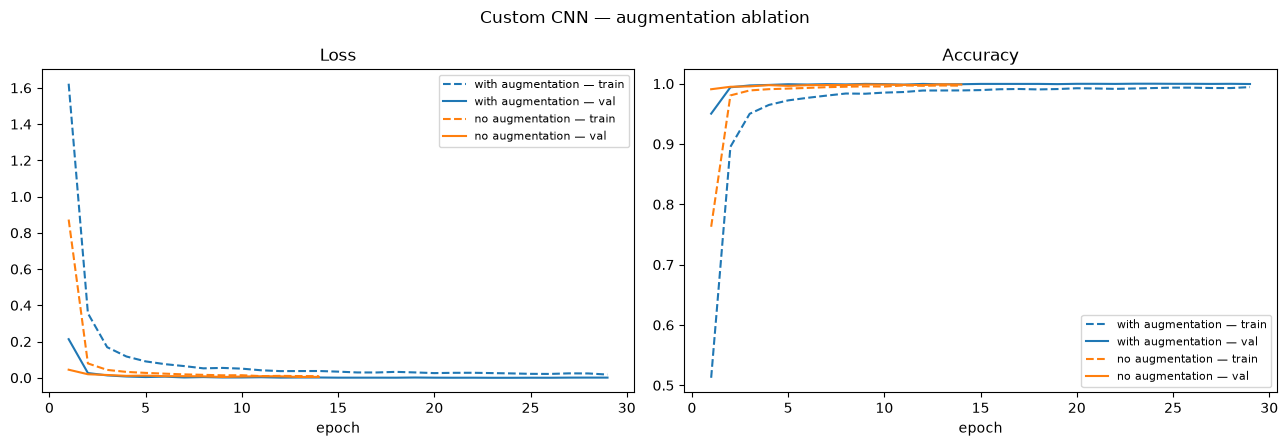

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for h, name, c in [(history_df, "with augmentation", "tab:blue"), (history_noaug, "no augmentation", "tab:orange")]:
    axes[0].plot(h.epoch, h.train_loss, ls="--", c=c, label=f"{name} — train")
    axes[0].plot(h.epoch, h.val_loss, c=c, label=f"{name} — val")
    axes[1].plot(h.epoch, h.train_acc, ls="--", c=c, label=f"{name} — train")
    axes[1].plot(h.epoch, h.val_acc, c=c, label=f"{name} — val")
axes[0].set_title("Loss"); axes[1].set_title("Accuracy")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.suptitle("Custom CNN — augmentation ablation")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_augmentation_curves.png", dpi=150)
plt.show()

## 11. Save config & metrics

- `configs/custom_cnn.json`: every setting, for reproducibility.
- `results/custom_cnn/metrics.json`: the row for the group's model-comparison table.

In [22]:
def jsonable(d):
    return {k: (round(float(v), 4) if isinstance(v, (float, np.floating)) else
                int(v) if isinstance(v, np.integer) else v) for k, v in d.items()}


with open(CONFIG_DIR / "custom_cnn.json", "w") as f:
    json.dump({**CONFIG, "train_size": int(len(train_idx)), "val_size": int(len(val_idx)),
               "test_size": int(len(y_test))}, f, indent=2)

summary = {
    "model": CONFIG["model_name"],
    "test": jsonable(test_metrics),
    "validation": jsonable(val_metrics),
    "supplementary_test": jsonable(supplementary),
    "confidence": jsonable(confidence_stats),
    "spearman_train_count_vs_f1": round(float(spearman), 4),
    "efficiency": jsonable(efficiency),
    "ablation_no_augmentation": {"test": jsonable(test_noaug), "validation": jsonable(val_noaug),
                                 "best_epoch": info_noaug["best_epoch"], "epochs_run": info_noaug["epochs_run"]},
}
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Model comparison row:")
display(pd.DataFrame([{
    "Model": CONFIG["model_name"], "Accuracy": test_metrics["accuracy"],
    "Macro Precision": test_metrics["precision_macro"], "Macro Recall": test_metrics["recall_macro"],
    "Macro F1": test_metrics["f1_macro"], "Params": n_params,
    "Train time (min)": efficiency["train_time_min"], "Device": DEVICE_NAME,
}]).round(4))

print("Saved:")
for p in sorted([CONFIG_DIR / "custom_cnn.json", *RESULTS_DIR.iterdir()]):
    print("  ", p.relative_to(ROOT))

Model comparison row:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Params,Train time (min),Device
0,Custom CNN,0.9949,0.9922,0.9935,0.9927,2396171,53.02,Apple MPS (arm64)


Saved:
   configs/custom_cnn.json
   results/custom_cnn/REPORT_NOTES.md
   results/custom_cnn/ablation_augmentation.csv
   results/custom_cnn/ablation_augmentation_curves.png
   results/custom_cnn/augmentation_examples.png
   results/custom_cnn/confidence_histogram.png
   results/custom_cnn/confusion_matrix.csv
   results/custom_cnn/confusion_matrix.png
   results/custom_cnn/f1_vs_class_frequency.png
   results/custom_cnn/history_main.csv
   results/custom_cnn/history_no_aug.csv
   results/custom_cnn/layer_parameters.csv
   results/custom_cnn/learning_curves.png
   results/custom_cnn/metrics.json
   results/custom_cnn/misclassified_examples.png
   results/custom_cnn/per_class_f1.png
   results/custom_cnn/per_class_metrics.csv
   results/custom_cnn/split_class_counts.csv
   results/custom_cnn/top_confusions.csv
